测试三 （3） 稳定I状态比例关于信息传播率lambda在不同组移动概率g与σ的变化关系 

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1. 辅助函数
# ---------------------------
def compute_epsilon(states, alpha, epsilon0):
    """
    计算激活因子 epsilon_i:
      如果居住点 i 的局部有意识比例 p_A = (AS + AI) 超过阈值 alpha,
      则 epsilon_i = epsilon0;否则为 0。
    参数:
      states: (N,5) 数组，每行分别为 [US, AS, AI, UR, AR] 的比例
      alpha: 意识阈值
      epsilon0: 激活常数
    返回:
      epsilon: (N,) 数组
    """
    p_A = states[:, 1] + states[:, 2] + states[:, 4]  # 取 AS + AI + AR 作为有意识水平
    epsilon = np.where(p_A > alpha, epsilon0, 0.0)
    return epsilon


def compute_effective_awareness(n, states, g_i, R):
    """
    计算每个中转站 j 的过客有效意识比例 tilde_p_j^A(t):
    tilde_p_j^A = (sum_i (n_i * g_i * R[i,j] * p_A^(i))) / (sum_i (n_i * g_i * R[i,j]))
    其中 p_A^(i) = states[i,1] + states[i,2]
    参数:
      n: (N,) 各居住点人口数
      states: (N,5) 每个居住点状态比例
      g_i: (N,) 居住点迁移率
      R: (N, M) 居住点到中转站权重矩阵
    返回:
      tilde_p_A: (M,) 数组
    """
    N = len(n)
    M = R.shape[1]
    n_out = n * g_i  
    p_A_res = states[:, 1] + states[:, 2] + states[:, 4]
    tilde_p_A = np.zeros(M)
    for j in range(M):
        numerator = 0.0  # 分子
        denominator = 0.0 # 分母
        for i in range(N):
            flow = n_out[i] * R[i, j]
            numerator += flow * p_A_res[i]
            denominator += flow
        tilde_p_A[j] = numerator / denominator if denominator > 0 else 0.0
    return tilde_p_A

def compute_awareness_conversion(R, lambda1, tilde_p_A):
    """
    计算每个居住点 i 的意识转换概率 r_i:
      r_i = 1 - ∏_{j=1}^{M} [1 - lambda1 * A[i,j] * tilde_p_A[j]]
      其中 A[i,j] = 1 当且仅当物理层权重 R[i,j] > 0(否则为 0)
    参数:
      R: (N, M) 物理层迁移权重矩阵
      lambda1: 信息接收率
      tilde_p_A: (M,) 中转站的过客有效意识比例
    返回:
      r: (N,) 数组
    """
    N, M = R.shape
    
    # 生成信息层二值矩阵 A
    A = (R > 0).astype(int)  # 直接根据物理层权重是否非零生成二值矩阵
    
    r = np.zeros(N)
    for i in range(N):
        prod = 1.0
        for j in range(M):
            # 只有当物理层存在连接时（R[i,j] > 0），信息层才有边（A[i,j]=1）
            prod *= (1 - lambda1 * R[i, j] * tilde_p_A[j])
        r[i] = 1 - prod
    return r

def compute_infection_residence(n, states, g_i, beta_U, beta_A):
    """
    计算居住点内部的感染概率：
      n_remain = n_i * (1 - g_i) 为留在居住点的人数
      p_I = AI 状态比例
      N_U = 1 - [1 - beta_U * p_I]^(n_remain)
      N_A = 1 - [1 - beta_A * p_I]^(n_remain)
    参数:
      n: (N,) 人口数
      states: (N,5) 状态比例数组；使用 states[:,2] 作为 AI 比例
      g_i: (N,) 迁移率
      beta_U, beta_A: 感染敏感度参数
    返回:
      N_U, N_A: (N,) 数组
    """
    n_remain = n * (1 - g_i)
    p_I = states[:, 2]
    # p_I = np.clip(states[:, 2], 0, 1)  # 确保 p_I ∈ [0,1]
    # 采用 np.power 计算 (1 - sigma * p_I)^(n_remain)
    N_U = 1 - np.power(1 - beta_U * p_I, n_remain)
    N_A = 1 - np.power(1 - beta_A * p_I, n_remain)
    return N_U, N_A

def compute_infection_transit(n, states, g_i, R, beta_U, beta_A):
    """
    计算中转站层面的感染概率：
      对于中转站 j,计算每个居住点 k 流向 j的人数 n_{k->j} = n_k * g_k * R[k, j]
      然后 M_j^U = 1 - sum_k [1 - beta_U * p_k^I]^(n_{k->j})
           M_j^A = 1 - sum_k [1 - beta_A * p_k^I]^(n_{k->j})
    参数:
      n, states, g_i, R, beta_U, beta_A(含义同上)
    返回:
      M_U, M_A: (M,) 数组
    """
    N, M = R.shape
    M_U = np.zeros(M)
    M_A = np.zeros(M)
    for j in range(M):
        sum_U = 1.0
        sum_A = 1.0
        for k in range(N):
            n_to_j = n[k] * g_i[k] * R[k, j]
            p_I = states[k, 2]
            sum_U *= np.power(1 - beta_U * p_I, n_to_j)
            sum_A *= np.power(1 - beta_A * p_I, n_to_j)
        M_U[j] = 1 - sum_U
        M_A[j] = 1 - sum_A
    return M_U, M_A

def compute_overall_infection(n, states, g_i, R, N_U, N_A, M_U, M_A):
    """
    计算每个居住点 i 的总体感染概率：
      Q_i^U = (1 - g_i)*N_U[i] + g_i * sum_{j} R[i,j]*M_U[j]
      Q_i^A = (1 - g_i)*N_A[i] + g_i * sum_{j} R[i,j]*M_A[j]
    参数:
      n, states, g_i, R, N_U, N_A, M_U, M_A(含义如前)
    返回:
      Q_U, Q_A: (N,) 数组
    """
    N, M = R.shape
    Q_U = np.zeros(N)
    Q_A = np.zeros(N)
    for i in range(N):
        sum_MU = np.sum(R[i, :] * M_U)
        sum_MA = np.sum(R[i, :] * M_A)
        Q_U[i] = (1 - g_i[i]) * N_U[i] + g_i[i] * sum_MU
        Q_A[i] = (1 - g_i[i]) * N_A[i] + g_i[i] * sum_MA
    return Q_U, Q_A


def update_states(states, r, Q_U, Q_A, mu1, mu2):
    """
    根据状态更新公式更新居住点内各状态比例：
      p_US(t+1) = p_US*(1-r)*(1-Q_U) + p_AS*mu1*(1-Q_U)
      p_AS(t+1) = p_AS*(1-mu1)*(1-Q_A) + p_US*r*(1-Q_A)
      p_AI(t+1) = p_AI*(1-mu2) + p_AS*(1-mu1)*Q_A + p_AS*mu1*Q_U +
                  p_US*(1-r)*Q_U + p_US*r*Q_A
      p_UR(t+1) = p_AI*mu1*mu2 + p_AR*mu1 + p_UR*(1-r)
      p_AR(t+1) = p_AR*(1-mu1) + p_AI*(1-mu1)*mu2 + p_UR*r
    参数:
      states: (N,5) 当前状态比例
      r: (N,) 意识转换概率
      Q_U, Q_A: (N,) 感染概率
      mu1, mu2: 遗忘率、康复率
    返回:
      new_states: (N,5) 更新后的状态比例（每行归一化）
    """
    new_states = np.zeros_like(states)
    US = states[:, 0]
    AS = states[:, 1]
    AI = states[:, 2]
    UR = states[:, 3]
    AR = states[:, 4]
    
    new_states[:, 0] = US * (1 - r) * (1 - Q_U) + AS * mu1 * (1 - Q_U)
    new_states[:, 1] = AS * (1 - mu1) * (1 - Q_A) + US * r * (1 - Q_A)
    new_states[:, 2] = AI * (1 - mu2) + AS * (1 - mu1) * Q_A + AS * mu1 * Q_U + US * (1 - r) * Q_U + US * r * Q_A
    new_states[:, 3] = AI * mu1 * mu2 + AR * mu1 + UR * (1 - r)
    new_states[:, 4] = AR * (1 - mu1) + AI * (1 - mu1) * mu2 + UR * r

    # 归一化每个居住点的状态比例
    row_sums = new_states.sum(axis=1)
    row_sums[row_sums == 0] = 1e-10  # 避免除零
    new_states = new_states / row_sums[:, None]
    return new_states


def update_population(n, states, g_i, epsilon, R, T):
    """
    更新人口分布，仅通过 T 矩阵控制返回比例(无需 gamma_j)
    参数:
      n: (N,) 居住点人口数
      states: (N,5) 各居住点状态比例
      g_i: (N,) 迁移率
      epsilon: (N,) 激活因子
      R: (N, M) 行归一化的迁移矩阵（迁出）
      T: (N, M) 列归一化的返回矩阵（返回）
    返回:
      n_new: (N,) 更新后人口数
      new_states: (N,5) 更新后状态比例
    """
    N, M = R.shape
    F = n * g_i * epsilon

    # 剩余人口和状态
    X = states * n[:, None]
    X_remain = X - (X.T * (g_i * epsilon)).T
    n_remain = n - F

    # 计算中转站流入人口
    m = np.zeros(M)
    m_X = np.zeros((M, 5))
    for j in range(M):
        for i in range(N):
            flow = n[i] * g_i[i] * epsilon[i] * R[i, j]
            m[j] += flow
            m_X[j] += X[i] * g_i[i] * epsilon[i] * R[i, j]

    # 计算返回人口（直接使用 T 矩阵）
    flow_return = np.zeros(N)
    flow_return_X = np.zeros((N, 5))
    for j in range(M):
          for i in range(N):
              flow_return[i] += m[j] * T[i, j]
              flow_return_X[i] +=  m_X[j]  * T[i, j]

    # 更新人口和状态
    n_new = n_remain + flow_return
    X_new = X_remain + flow_return_X
    new_states = X_new / np.clip(n_new[:, None], 1e-10, None)
    return n_new, new_states


# ---------------------------
# 2. 主仿真流程
# ---------------------------
def main_simulation(Time, N, M, params):
    """
    主仿真流程
    参数:
      T: 总时间步数
      N: 居住点数量
      M: 中转站数量
      params: 参数字典，包含 lambda1, mu1, mu2, beta_U, beta_A, g, gamma, epsilon0, alpha, theta, kappa
    返回:
      state_history: (T, N, 5) 各时间步各居住点状态比例历史记录
      pop_history: (T, N) 各时间步各居住点人口数
    """
    lambda1 = params['lambda1']
    mu1 = params['mu1']
    mu2 = params['mu2']
    beta_U = params['beta_U']
    beta_A = params['beta_A']
    g_global = params['g']
    # gamma_global = params['gamma']
    epsilon0 = params['epsilon0']
    alpha = params['alpha']
    theta = params['theta']
    # kappa = params['kappa']

    # 居住点特异性迁移率和返回率（这里使用常数，可扩展为数组）
    g_i = np.full(N, theta * g_global)
    # gamma_i = np.full(N, kappa * gamma_global)
    
    # 设置返回率 gamma_j = 1(不一定)
    # gamma_j = np.full(M, kappa * gamma_global)  # 每个中转站有独立的返回率

    # 初始化各居住点人口（例如每个 500 人）和状态比例（US, AS, AI, UR, AR）
    n = np.full(N, 200.0)
    states = np.zeros((N, 5))
    states[:, 0] = 0.99  # US
    states[:, 2] = 0.01  # AI
    states = states / states.sum(axis=1, keepdims=True)
    
    # 初始化居住点与中转站之间的权重矩阵 R (N x M)，对称归一化：每个居住点行和为 1
    w = np.random.rand(N, M)
    R = w / w.sum(axis=1, keepdims=True)  # 行归一化（迁移）
    T = w / w.sum(axis=0, keepdims=True)  # 列归一化（返回）

    # 用于记录历史数据
    state_history = np.zeros((Time, N, 5))
    pop_history = np.zeros((Time, N))
    
    for t in range(Time):
        state_history[t] = states
        pop_history[t] = n
        
        # 1. 计算当前居住点局部有意识比例 p^A = AS + AI + AR
        # 2. 计算激活因子 epsilon: 若 p^A > alpha 则 epsilon = epsilon0，否则 0
        epsilon = compute_epsilon(states, alpha, epsilon0)
        
        # 2.5. 更新居住点的人口及状态（基于 MIR 过程） n_new为更新后的居住点人口数，states_new为更新后的居住点状态比例
        n_new, states_new = update_population(n, states, g_i, epsilon, R, T)

        # 3. 计算中转站的过客有效意识比例 tilde_p^A
        tilde_p_A = compute_effective_awareness(n, states_new, g_i, R)
        # 4. 计算居住点的意识转换概率 r
        r = compute_awareness_conversion(R, lambda1, tilde_p_A)
        # print('t', t, 'r', r)
        
        # 5. 计算居住点内部感染风险
        N_U, N_A = compute_infection_residence(n, states_new, g_i, beta_U, beta_A)
        # 6. 计算中转站层面的感染风险
        M_U, M_A = compute_infection_transit(n, states_new, g_i, R, beta_U, beta_A)
        # 7. 综合计算每个居住点的总体感染概率 Q
        Q_U, Q_A = compute_overall_infection(n, states_new, g_i, R, N_U, N_A, M_U, M_A)
        
        # 8. 更新居住点内部的疾病/意识状态
        states = update_states(states_new, r, Q_U, Q_A, mu1, mu2)
        n = n_new

        
    return state_history, pop_history


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed

# 参数设置
num_simulations = 20   # 每个参数组合的重复实验次数
Time = 150             # 仿真时间步长
N = 15                 # 居住点数量
M = 5                  # 中转站数量
sigma = 0.5            # β_A = σ*β_U

# 参数组合 (g, sigma)
param_combinations = [
    {'g': 0.6, 'sigma': 0.8, 'label': r'g = 0.6, $ \sigma$ = 0.8', 'color': '#0466c8', 'linestyle': '--',    'marker': 's', 'mfc': 'white', 'markevery': 3, 'markersize': 10},
    {'g': 0.6, 'sigma': 0.1, 'label': r'g = 0.6, $ \sigma$ = 0.1', 'color': '#4E9980', 'linestyle': '--',
     'marker': 'o', 'mfc': 'white', 'markevery': 3, 'markersize': 10},
    {'g': 0.1, 'sigma': 0.8, 'label': r'g = 0.1, $ \sigma$ = 0.8', 'color': '#BF3147', 'linestyle': '--',
     'marker': '^', 'mfc': 'white', 'markevery': 3, 'markersize': 10},
    {'g': 0.1, 'sigma': 0.1, 'label': r'g = 0.1, $ \sigma$ = 0.1', 'color': '#563E68', 'linestyle': '--',
     'marker': 'D', 'mfc': 'white', 'markevery': 3, 'markersize': 10}
]


# β1的扫描范围
lambda_values = np.arange(0.0, 1.05, 0.05)  

# 存储结果 (4组参数 × lambda1值 × 重复实验)
results_R = {combo['label']: np.zeros((len(lambda_values), num_simulations)) for combo in param_combinations}
results_A = {combo['label']: np.zeros((len(lambda_values), num_simulations)) for combo in param_combinations}

# 基础参数配置
base_params = {
    'mu1': 0.15, 
    'mu2': 0.20,
    'beta_U': 0.003, 
    # 'beta_A': 0.0015, 
    'epsilon0': 0.2, 
    'alpha': 0.3, 
    'theta': 1, 
    'kappa': 1
}

def simulate_steady_state(params):
    state_history, _ = main_simulation(Time, N, M, params)
    steady_state = state_history[-1]
    rho_R = np.mean(steady_state[:, 3])  # UR
    rho_A = np.mean(steady_state[:, 4])  # AR
    return rho_R, rho_A

# 并行计算
for combo in param_combinations:
    g = combo['g']
    sigma = combo['sigma']
    
    for i, lambda1 in enumerate(tqdm(lambda_values, desc=f"Scanning {combo['label']}")):
        params = base_params.copy()
        params['g'] = g
        params['lambda1'] = lambda1
        params['beta_A'] = sigma * params['beta_U']
        
        results = Parallel(n_jobs=-1)(
            delayed(simulate_steady_state)(params)
            for _ in range(num_simulations)
        )
        # 拆分 UR 和 AR
        rho_R_vals, rho_A_vals = zip(*results)
        results_R[combo['label']][i, :] = rho_R_vals
        results_A[combo['label']][i, :] = rho_A_vals


# 计算均值
mean_results_R = {k: np.mean(v, axis=1) for k, v in results_R.items()}
mean_results_A = {k: np.mean(v, axis=1) for k, v in results_A.items()}


Scanning g = 0.6, $ \sigma$ = 0.8:   0%|          | 0/21 [00:00<?, ?it/s]

Scanning g = 0.1, $ \sigma$ = 0.1: 100%|██████████| 21/21 [00:06<00:00,  3.28it/s]


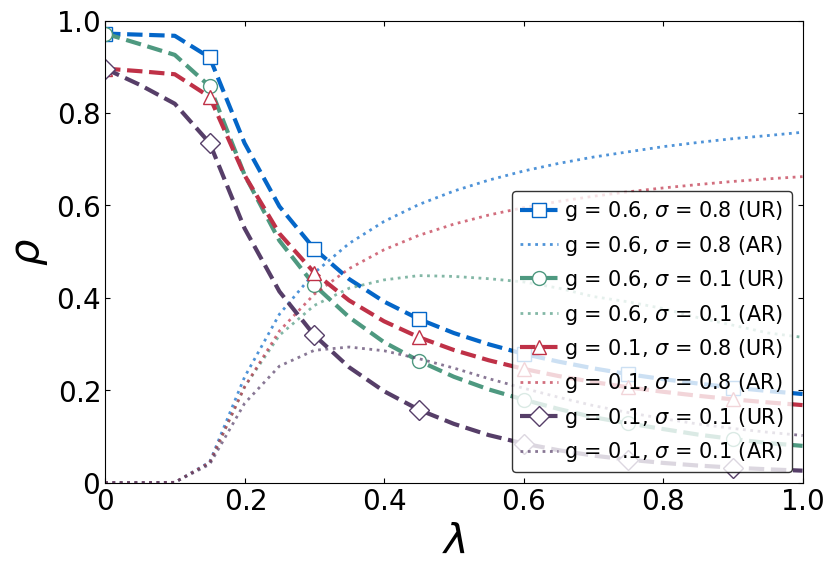

In [6]:
# 绘制曲线
plt.figure(figsize=(9, 6))
for combo in param_combinations:
    label = combo['label']
    # UR（ρ^R）曲线
    plt.plot(lambda_values, mean_results_R[label], 
             label=label + r' (UR)', 
             color=combo['color'], 
             linestyle=combo['linestyle'], 
             linewidth=3,
             marker=combo['marker'],
             mfc=combo['mfc'],
             markersize=combo['markersize'],
             markevery=combo['markevery'])
    
    # AR（ρ^A）曲线 - 用虚线、透明度或浅色区分
    plt.plot(lambda_values, mean_results_A[label], 
             label=label + r' (AR)', 
             color=combo['color'], 
             linestyle=':', 
             linewidth=2,
             alpha=0.7)


# 图表装饰
plt.xlabel(r'$\lambda$', fontsize=30)
plt.xticks([0.0, 0.20, 0.40, 0.60, 0.80, 1.00 ], [r'$0$', r'$0.2$', r'$0.4$', r'$0.6$', r'$0.8$', r'$1.0$' ], fontsize='20')
plt.xlim(0, 1.0)  # 强制 x 轴从 0 开始
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], [r'$0$', r'$0.2$', r'$0.4$', r'$0.6$', r'$0.8$', r'$1.0$'], fontsize='20')
plt.ylabel(r'$ \rho$ ', fontsize=30)
plt.ylim(0, 1.0)  # 强制 y 轴从 0 开始
# plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')


legend = plt.legend(
    loc='lower right',
    fontsize='15',
    handletextpad=0.3,    # 图标与文本的间距
    borderpad=0.4,          # 图例内边距
    handlelength=1.8,    # 统一图标宽度
)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)
# plt.tight_layout()

# 启用四面刻度
plt.tick_params(
    axis='both',      # 同时控制 x 和 y 轴
    which='both',     # 同时控制主刻度和次刻度
    top=True,         # 显示顶部刻度
    right=True,       # 显示右侧刻度
    labeltop=False,   # 不显示顶部刻度标签（避免重叠）
    labelright=False,  # 不显示右侧刻度标签（避免重叠）
    direction='in',   # 刻度朝内
)


# plt.savefig('R_vs_lambda1_multiple_conditions.png', dpi=300, bbox_inches='tight')
plt.show()